# Exploratory Data Analysis (EDA)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [8]:
df = pd.read_csv("D:\project\churn-prediction-service\data\\raw\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
print("The shape of the dataset is", df.shape)

The shape of the dataset is (7043, 21)


In [9]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

we got 3 numeric attributs **[SeniorCitizen, tenure, MonthlyCharges]** and the other attributes are categorical

In [10]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [33]:
df["SeniorCitizen"].value_counts()

SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64

- **16%** of the customers are under 65
- the average of duration that a customer stayed with the company is **32** month
- the average of charge that a customer payed to the company each month is **64.76** month

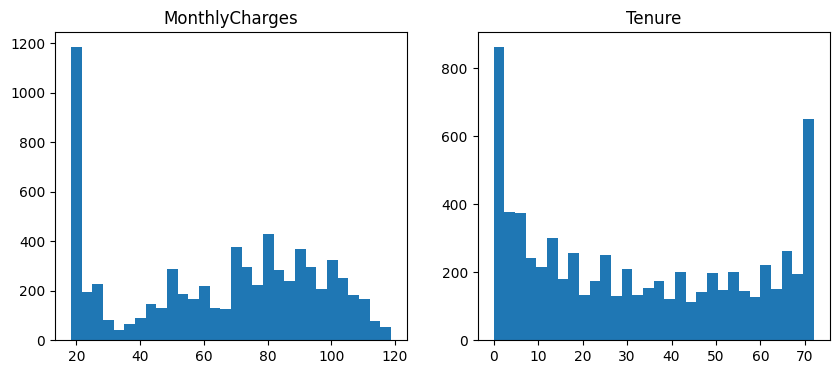

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))

ax[0].hist(df["MonthlyCharges"], bins=30)
ax[0].set_title("MonthlyCharges")

ax[1].hist(df["tenure"], bins=30)
ax[1].set_title("Tenure")

plt.show()

In [11]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [12]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

- There are a lot of imbalanced attributes
- There is no missing values

In [13]:
df['Churn'].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

## Initial Data Overview

### Dataset Shape
We first check the shape of the dataset to understand:
- Number of rows (7043)
- Number of columns (21)

This gives a quick overview of dataset size and complexity.

Observation:
- The dataset contains `7043` rows and `21` columns.

---
### Columns explanation
1. `customerID` has an `object` dtype and it's an identifier to each customer
2. `gender` has an `object` dtype and it's an identifier to each sex
3. `SeniorCitizen` has an `int64` dtype and it's an identifier to each customer whether he is above '65' or not. 
    - `1` means he is 65 or older
    - `0` means he is younger than 65
4. `Partner` has an `object` dtype and it's an indication to the user having a partner or not
5. `dependents` has an `object` dtype and it's an indication to the user having people who rely on them financially or not
6. `tenure` has an `int` dtype and it's an indication to the number of months that the user stayed with the company
7. `PhoneService` has an `object` dtype and it's an indication to the customer having PhoneService or not
8. `MultipleLines`has an `object` dtype and it's an indication to the customer having MultipleLines or not even having a PhoneService
    - `yes` means he has MultipleLines
    - `No` means he hasn't MultipleLines but has a phone service
    - `No phone service` means he hasn't MultipleLines and a phone service
9. `InternetService` has an `object` dtype and it's an indication to the customer `DSL` or `Fiber optic` or `not having both`
10. `OnlineSecurity` has an `object` dtype and it's an indication to the customer having `OnlineSecurity` or not having `internet service at all`
11. `OnlineBackup` has an `object` dtype and it's an indication to the customer having `OnlineBackup` or not having `internet service at all`
12. `DeviceProtection` has an `object` dtype and it's an indication to the customer having `DeviceProtection` or not having `internet service at all`
13. `TechSupport` has an `object` dtype and it's an indication to the customer having `TechSupport` or not having `internet service at all`
14. `StreamingTV` has an `object` dtype and it's an indication to the customer having `StreamingTV` or not having `internet service at all`
15. `StreamingMovies` has an `object` dtype and it's an indication to the customer having `StreamingMovies` or not having `internet service at all`
16. `Contract` has an `object` dtype and it's an indication to the customer having `Month-to-month` or having `One year` or `Two year` contract
17. `PaperlessBilling` has an `object` dtype and it's an indication to the customer getting the bills via `email` or `mail`
18. `PaymentMethod` has an `object` dtype and it's an indication to the customer method of paying 
19. `MonthlyCharges` has an `float64` dtype and it's an indication to how much does the customer pays per month
20. `TotalCharges` has an `object` dtype and it's an indication to how much does the customer pays 
21. `Churn` has an `object` dtype and it's an indication to Whether the customer churned
---
### Target Column explanation
- in this dataset the percentage of customers that don't churn is **73.5%** 
- this will cause a major bias if it hasn't been handled